# NER com BiLSTM-CRF e Modelos BERT para o dataset decicontas.br

Este notebook implementa e avalia modelos de NER baseados em:
1. **BiLSTM-CRF** — arquitetura clássica de sequência com camada CRF
2. **BERTimbau** — BERT pré-treinado em português (neuralmind/bert-base-portuguese-cased)
3. **Legal-BERTimbau / albertina-ptbr** — variantes adaptadas ao domínio

O dataset decicontas.br contém 178 decisões anotadas do TCE/RN com 6 tipos de entidade:
MULTA_FIXA, MULTA_PERCENTUAL, OBRIGACAO, OBRIGACAO_MULTA, RECOMENDACAO, RESSARCIMENTO.

**Métricas**: Token-level (Precision, Recall, F1) e Span-level (F1 com IoU ≥ 0.5), compatíveis com o artigo decicontas.br.

## 2. Carregamento e Preparação dos Dados

In [1]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="eduardoplima-imd",
    # Set the wandb project where this run will be logged.
    project="my-awesome-project",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/eduardo/.netrc
wandb: Currently logged in as: eduardoplima (eduardoplima-imd) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


acc,▁▆▆██▇██
loss,█▄▂▄▂▁▂▁
acc,0.76912
loss,0.25733


In [46]:
import json
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [3]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: mps


In [10]:
def load_decicontas():
    """Carrega o dataset decicontas via get_decicontas_df e converte para formato BIO."""
    df = get_decicontas_df()
    
    samples = []
    for _, row in df.iterrows():
        text = row['data']['text']
        annotations = row['annotations']
        
        # Extrair results de dentro da estrutura Label Studio
        results = []
        for ann in annotations:
            if isinstance(ann, dict) and 'result' in ann:
                results.extend(ann['result'])
            elif isinstance(ann, dict) and 'value' in ann:
                results.append(ann)
        
        spans = []
        for r in results:
            if 'value' in r and 'labels' in r['value']:
                val = r['value']
                spans.append({
                    'start': val['start'],
                    'end': val['end'],
                    'label': val['labels'][0]
                })
        
        samples.append({'text': text, 'spans': spans})
    
    
    annotated = [s for s in samples if s['spans']]
    print(f'Total de amostras: {len(samples)}, Anotadas: {len(annotated)}')
    return annotated

samples = load_decicontas()

Total de amostras: 1425, Anotadas: 235


In [12]:
import re

def simple_tokenize(text):
    """Tokenização simples que preserva offsets de caractere."""
    tokens = []
    for m in re.finditer(r'\S+', text):
        tokens.append({
            'text': m.group(),
            'start': m.start(),
            'end': m.end()
        })
    return tokens

def spans_to_bio(tokens, spans):
    """Converte character-level spans para tags BIO em nível de token."""
    labels = ['O'] * len(tokens)
    
    for span in spans:
        s_start, s_end, s_label = span['start'], span['end'], span['label']
        first = True
        for i, tok in enumerate(tokens):
            # Token sobrepõe com o span
            if tok['start'] < s_end and tok['end'] > s_start:
                if first:
                    labels[i] = f'B-{s_label}'
                    first = False
                else:
                    labels[i] = f'I-{s_label}'
    
    return labels

# Converter tudo para formato BIO
bio_data = []
for s in samples:
    tokens = simple_tokenize(s['text'])
    labels = spans_to_bio(tokens, s['spans'])
    bio_data.append({
        'tokens': [t['text'] for t in tokens],
        'token_offsets': tokens,
        'labels': labels,
        'text': s['text'],
        'spans': s['spans']
    })

# Estatísticas
all_labels = [l for s in bio_data for l in s['labels']]
label_counts = Counter(all_labels)
print('Distribuição de tags BIO:')
for k, v in sorted(label_counts.items()):
    print(f'  {k}: {v}')

# Construir vocabulários
unique_labels = sorted(set(all_labels))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
print(f'\nTotal de tags: {len(unique_labels)}')
print(unique_labels)

Distribuição de tags BIO:
  B-MULTA: 204
  B-OBRIGACAO: 120
  B-RECOMENDACAO: 58
  B-RESSARCIMENTO: 63
  I-MULTA: 11127
  I-OBRIGACAO: 7849
  I-RECOMENDACAO: 2131
  I-RESSARCIMENTO: 2897
  O: 29829

Total de tags: 9
['B-MULTA', 'B-OBRIGACAO', 'B-RECOMENDACAO', 'B-RESSARCIMENTO', 'I-MULTA', 'I-OBRIGACAO', 'I-RECOMENDACAO', 'I-RESSARCIMENTO', 'O']


In [13]:
# Split 80/10/10
train_data, temp_data = train_test_split(bio_data, test_size=0.2, random_state=SEED)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED)

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

Train: 188, Val: 23, Test: 24


## 3. Funções de Avaliação

Métricas compatíveis com o artigo:
- **Token-level**: Precision, Recall, F1 (micro) sobre sequências BIO
- **Span-level**: F1 com IoU ≥ 0.5 para correspondência de spans
- **seqeval**: Avaliação padrão CoNLL para NER

In [14]:
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score
from seqeval.metrics import precision_score as seq_precision_score
from seqeval.metrics import recall_score as seq_recall_score
from sklearn.metrics import classification_report, f1_score


def compute_token_metrics(true_labels_flat, pred_labels_flat):
    """Métricas token-level (exclui 'O')."""
    entity_labels = sorted(set(true_labels_flat + pred_labels_flat) - {'O'})
    report = classification_report(
        true_labels_flat, pred_labels_flat,
        labels=entity_labels, output_dict=True, zero_division=0
    )
    micro_f1 = f1_score(
        true_labels_flat, pred_labels_flat,
        labels=entity_labels, average='micro', zero_division=0
    )
    return report, micro_f1


def extract_spans_from_bio(labels):
    """Extrai spans (start_idx, end_idx, label) de uma sequência BIO."""
    spans = []
    current_label = None
    start = None
    for i, tag in enumerate(labels):
        if tag.startswith('B-'):
            if current_label is not None:
                spans.append((start, i, current_label))
            current_label = tag[2:]
            start = i
        elif tag.startswith('I-'):
            if current_label is None or tag[2:] != current_label:
                if current_label is not None:
                    spans.append((start, i, current_label))
                current_label = tag[2:]
                start = i
        else:
            if current_label is not None:
                spans.append((start, i, current_label))
                current_label = None
    if current_label is not None:
        spans.append((start, len(labels), current_label))
    return spans


def compute_span_f1(true_labels_list, pred_labels_list, iou_threshold=0.5):
    """Span-level F1 com IoU >= threshold."""
    tp, fp, fn = 0, 0, 0
    per_entity = {}
    
    for true_labels, pred_labels in zip(true_labels_list, pred_labels_list):
        true_spans = extract_spans_from_bio(true_labels)
        pred_spans = extract_spans_from_bio(pred_labels)
        
        matched_true = set()
        matched_pred = set()
        
        for pi, ps in enumerate(pred_spans):
            for ti, ts in enumerate(true_spans):
                if ps[2] == ts[2] and ti not in matched_true:
                    # Calcular IoU
                    inter_start = max(ps[0], ts[0])
                    inter_end = min(ps[1], ts[1])
                    intersection = max(0, inter_end - inter_start)
                    union = (ps[1] - ps[0]) + (ts[1] - ts[0]) - intersection
                    iou = intersection / union if union > 0 else 0
                    
                    if iou >= iou_threshold:
                        matched_true.add(ti)
                        matched_pred.add(pi)
                        label = ps[2]
                        per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                        per_entity[label]['tp'] += 1
                        break
        
        for pi, ps in enumerate(pred_spans):
            if pi not in matched_pred:
                fp += 1
                label = ps[2]
                per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                per_entity[label]['fp'] += 1
        
        for ti, ts in enumerate(true_spans):
            if ti not in matched_true:
                fn += 1
                label = ts[2]
                per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                per_entity[label]['fn'] += 1
        
        tp += len(matched_pred)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    per_entity_f1 = {}
    for label, counts in per_entity.items():
        p = counts['tp'] / (counts['tp'] + counts['fp']) if (counts['tp'] + counts['fp']) > 0 else 0
        r = counts['tp'] / (counts['tp'] + counts['fn']) if (counts['tp'] + counts['fn']) > 0 else 0
        per_entity_f1[label] = 2 * p * r / (p + r) if (p + r) > 0 else 0
    
    return {'precision': precision, 'recall': recall, 'f1': f1, 'per_entity_f1': per_entity_f1}


def full_evaluation(true_labels_list, pred_labels_list, model_name='Model'):
    """Avaliação completa: token-level + span-level + seqeval."""
    # Flatten para token-level
    true_flat = [l for seq in true_labels_list for l in seq]
    pred_flat = [l for seq in pred_labels_list for l in seq]
    
    _, token_f1 = compute_token_metrics(true_flat, pred_flat)
    span_results = compute_span_f1(true_labels_list, pred_labels_list)
    
    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    print(f'Token-level F1 (micro, excl. O): {token_f1:.4f}')
    print(f'Span-level F1 (IoU >= 0.5):      {span_results["f1"]:.4f}')
    print(f'Span-level Precision:             {span_results["precision"]:.4f}')
    print(f'Span-level Recall:                {span_results["recall"]:.4f}')
    print(f'\nPer-entity Span F1:')
    for ent, f1_val in sorted(span_results['per_entity_f1'].items()):
        print(f'  {ent}: {f1_val:.4f}')
    
    # seqeval report
    print(f'\nseqeval Classification Report:')
    print(seq_classification_report(true_labels_list, pred_labels_list, zero_division=0))
    
    return {
        'model': model_name,
        'token_f1': token_f1,
        'span_f1': span_results['f1'],
        'span_precision': span_results['precision'],
        'span_recall': span_results['recall'],
        'per_entity_f1': span_results['per_entity_f1']
    }

---
## 4. Modelo BiLSTM-CRF

Implementação de um BiLSTM-CRF com embeddings treináveis.  
Referência: Huang et al. (2015), Lample et al. (2016).

In [28]:
!pip install TorchCRF
from TorchCRF import CRF


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:


# Construir vocabulário de palavras
word_freq = Counter()
for s in bio_data:
    for t in s['tokens']:
        word_freq[t.lower()] += 1

# Manter palavras com freq >= 1
vocab = ['<PAD>', '<UNK>'] + [w for w, c in word_freq.most_common() if c >= 1]
word2id = {w: i for i, w in enumerate(vocab)}
print(f'Vocab size: {len(vocab)}')


class NERDataset(Dataset):
    def __init__(self, data, word2id, label2id, max_len=512):
        self.data = data
        self.word2id = word2id
        self.label2id = label2id
        self.max_len = max_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        tokens = self.data[idx]['tokens'][:self.max_len]
        labels = self.data[idx]['labels'][:self.max_len]
        
        input_ids = [self.word2id.get(t.lower(), self.word2id['<UNK>']) for t in tokens]
        label_ids = [self.label2id[l] for l in labels]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(label_ids, dtype=torch.long),
            'length': len(input_ids)
        }


def collate_fn(batch):
    max_len = max(b['length'] for b in batch)
    
    input_ids = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels = torch.zeros(len(batch), max_len, dtype=torch.long)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    
    for i, b in enumerate(batch):
        l = b['length']
        input_ids[i, :l] = b['input_ids']
        labels[i, :l] = b['labels']
        mask[i, :l] = True
    
    return {'input_ids': input_ids, 'labels': labels, 'mask': mask}


train_dataset = NERDataset(train_data, word2id, label2id)
val_dataset = NERDataset(val_data, word2id, label2id)
test_dataset = NERDataset(test_data, word2id, label2id)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

Vocab size: 4317


In [31]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim // 2,
            num_layers=2, bidirectional=True, batch_first=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
    
    def forward(self, input_ids, labels=None, mask=None):
        embeds = self.dropout(self.embedding(input_ids))
        lstm_out, _ = self.lstm(embeds)
        emissions = self.fc(self.dropout(lstm_out))
        
        if labels is not None:
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            return self.crf.decode(emissions, mask=mask)


EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LABELS = len(unique_labels)

bilstm_model = BiLSTM_CRF(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=NUM_LABELS
).to(device)

print(f'Parâmetros: {sum(p.numel() for p in bilstm_model.parameters()):,}')

Parâmetros: 1,214,444


In [32]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = AdamW(bilstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 50
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 10

for epoch in range(EPOCHS):
    # Train
    bilstm_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        loss = bilstm_model(
            batch['input_ids'].to(device),
            batch['labels'].to(device),
            batch['mask'].to(device)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    
    # Validate
    bilstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            loss = bilstm_model(
                batch['input_ids'].to(device),
                batch['labels'].to(device),
                batch['mask'].to(device)
            )
            val_loss += loss.item()
    
    avg_train = total_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    scheduler.step(avg_val)
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(bilstm_model.state_dict(), 'best_bilstm_crf.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')
    
    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

print('Treinamento BiLSTM-CRF concluído.')

Epoch 5/50 | Train Loss: 104.1475 | Val Loss: 164.0096
Epoch 10/50 | Train Loss: 49.7440 | Val Loss: 157.1350
Epoch 15/50 | Train Loss: 27.4097 | Val Loss: 168.8123
Early stopping at epoch 17
Treinamento BiLSTM-CRF concluído.


In [33]:
# Carregar melhor modelo e avaliar no test set
bilstm_model.load_state_dict(torch.load('best_bilstm_crf.pt', map_location=device))
bilstm_model.eval()

all_true_bilstm = []
all_pred_bilstm = []

with torch.no_grad():
    for i, sample in enumerate(test_data):
        tokens = sample['tokens'][:512]
        true_labels = sample['labels'][:512]
        
        input_ids = torch.tensor(
            [[word2id.get(t.lower(), word2id['<UNK>']) for t in tokens]],
            dtype=torch.long
        ).to(device)
        mask = torch.ones_like(input_ids, dtype=torch.bool).to(device)
        
        pred_ids = bilstm_model(input_ids, mask=mask)[0]
        pred_labels = [id2label[p] for p in pred_ids]
        
        all_true_bilstm.append(true_labels)
        all_pred_bilstm.append(pred_labels)

bilstm_results = full_evaluation(all_true_bilstm, all_pred_bilstm, 'BiLSTM-CRF')


  BiLSTM-CRF
Token-level F1 (micro, excl. O): 0.8277
Span-level F1 (IoU >= 0.5):      0.6667
Span-level Precision:             0.7812
Span-level Recall:                0.5814

Per-entity Span F1:
  MULTA: 0.5789
  OBRIGACAO: 0.8571
  RECOMENDACAO: 0.4000
  RESSARCIMENTO: 0.7273

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.00      0.00      0.00        20
    OBRIGACAO       0.00      0.00      0.00        12
 RECOMENDACAO       0.00      0.00      0.00         4
RESSARCIMENTO       0.00      0.00      0.00         7

    micro avg       0.00      0.00      0.00        43
    macro avg       0.00      0.00      0.00        43
 weighted avg       0.00      0.00      0.00        43



---
## 5. Modelos BERT para NER (Token Classification)

Fine-tuning de modelos BERT pré-treinados em português para classificação de tokens.

Modelos avaliados:
1. **BERTimbau** (`neuralmind/bert-base-portuguese-cased`) — BERT base para PT-BR
2. **BERTimbau Large** (`neuralmind/bert-large-portuguese-cased`) — versão large
3. **XLM-RoBERTa** (`xlm-roberta-base`) — multilingual, forte em NER cross-lingual

Todos usam `AutoModelForTokenClassification` do HuggingFace.

In [34]:
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    EarlyStoppingCallback
)


class NERTokenDataset(Dataset):
    """Dataset que alinha BIO labels com sub-tokens do tokenizer BERT."""
    
    def __init__(self, data, tokenizer, label2id, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        tokens = sample['tokens']
        labels = sample['labels']
        
        # Tokenizar com is_split_into_words=True para alinhar sub-tokens
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_length,
            truncation=True,
            padding=False,
            return_offsets_mapping=False
        )
        
        # Alinhar labels com word_ids
        word_ids = encoding.word_ids()
        aligned_labels = []
        previous_word_id = None
        
        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)  # tokens especiais
            elif word_id != previous_word_id:
                aligned_labels.append(self.label2id[labels[word_id]])
            else:
                # Sub-tokens: copiar label do primeiro sub-token
                lbl = labels[word_id]
                if lbl.startswith('B-'):
                    aligned_labels.append(self.label2id['I-' + lbl[2:]])
                else:
                    aligned_labels.append(self.label2id[lbl])
            previous_word_id = word_id
        
        encoding['labels'] = aligned_labels
        return {k: torch.tensor(v) for k, v in encoding.items()}


def compute_metrics_hf(eval_pred):
    """Callback de métricas para o Trainer."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)
    
    true_labels_list = []
    pred_labels_list = []
    
    for pred_seq, label_seq in zip(predictions, labels):
        true_seq = []
        pred_seq_clean = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_seq.append(id2label[l])
                pred_seq_clean.append(id2label[p])
        true_labels_list.append(true_seq)
        pred_labels_list.append(pred_seq_clean)
    
    return {
        'f1': seq_f1_score(true_labels_list, pred_labels_list, zero_division=0),
        'precision': seq_precision_score(true_labels_list, pred_labels_list, zero_division=0),
        'recall': seq_recall_score(true_labels_list, pred_labels_list, zero_division=0),
    }

In [ ]:
def train_and_evaluate_bert(model_name, train_data, val_data, test_data,
                            label2id, id2label, epochs=15, batch_size=8, lr=3e-5):
    """
    Fine-tune e avalia um modelo BERT para NER.
    Retorna métricas e predições no test set.
    """
    print(f'\n{"#"*60}')
    print(f'  Treinando: {model_name}')
    print(f'{"#"*60}')
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    train_ds = NERTokenDataset(train_data, tokenizer, label2id)
    val_ds = NERTokenDataset(val_data, tokenizer, label2id)
    test_ds = NERTokenDataset(test_data, tokenizer, label2id)
    
    data_collator = DataCollatorForTokenClassification(tokenizer, padding=True)
    
    output_dir = f'./results_{model_name.replace("/", "_")}'
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        save_total_limit=2,
        logging_steps=10,
        fp16=torch.cuda.is_available(),
        report_to='none',
        seed=SEED,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics_hf,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )
    
    trainer.train()
    
    # Predição no test set
    predictions = trainer.predict(test_ds)
    preds = np.argmax(predictions.predictions, axis=2)
    labels_arr = predictions.label_ids
    
    true_labels_list = []
    pred_labels_list = []
    
    for pred_seq, label_seq in zip(preds, labels_arr):
        true_seq = []
        pred_seq_clean = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_seq.append(id2label[l])
                pred_seq_clean.append(id2label[p])
        true_labels_list.append(true_seq)
        pred_labels_list.append(pred_seq_clean)
    
    results = full_evaluation(true_labels_list, pred_labels_list, model_name)
    
    # Cleanup
    del model, trainer, train_ds, val_ds, test_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return results

In [38]:
# Lista de modelos BERT a avaliar
BERT_MODELS = [
    'neuralmind/bert-base-portuguese-cased',     # BERTimbau base
    'neuralmind/bert-large-portuguese-cased',     # BERTimbau large
    'xlm-roberta-base',                           # XLM-RoBERTa
]

# Para adicionar outros modelos relevantes ao domínio jurídico PT-BR, 
# descomente as linhas abaixo:
BERT_MODELS += [
     'rufimelo/Legal-BERTimbau-base',            # BERT jurídico PT
     'PORTULAN/albertina-ptbr',                   # Albertina PT-BR
]

In [47]:
all_results = [bilstm_results]  # já temos o BiLSTM-CRF

for model_name in BERT_MODELS:
    try:
        results = train_and_evaluate_bert(
            model_name=model_name,
            train_data=train_data,
            val_data=val_data,
            test_data=test_data,
            label2id=label2id,
            id2label=id2label,
            epochs=15,
            batch_size=2,    # reduzido de 8 para evitar OOM
            lr=3e-5
        )
        all_results.append(results)
    except Exception as e:
        print(f'ERRO com {model_name}: {e}')


############################################################
  Treinando: neuralmind/bert-base-portuguese-cased
############################################################


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 54331.79it/s]
BertForTokenClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.504248,0.586145,0.050420,0.029851,0.162162
2,0.114197,0.469987,0.123457,0.080000,0.270270
3,0.200392,0.481026,0.222222,0.157303,0.378378
4,0.112749,0.540713,0.277778,0.186916,0.540541
5,0.031659,0.497677,0.389381,0.289474,0.594595
6,0.004700,0.542517,0.390244,0.279070,0.648649
7,0.005084,0.552320,0.400000,0.301370,0.594595
8,0.003850,0.566125,0.389831,0.283951,0.621622
9,0.019723,0.544246,0.422018,0.319444,0.621622
10,0.011296,0.578340,0.440367,0.333333,0.648649


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.95it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


  neuralmind/bert-base-portuguese-cased
Token-level F1 (micro, excl. O): 0.9336
Span-level F1 (IoU >= 0.5):      0.7238
Span-level Precision:             0.6129
Span-level Recall:                0.8837

Per-entity Span F1:
  MULTA: 0.8000
  OBRIGACAO: 0.5500
  RECOMENDACAO: 0.6667
  RESSARCIMENTO: 1.0000

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.52      0.65      0.58        20
    OBRIGACAO       0.36      0.83      0.50        12
 RECOMENDACAO       1.00      0.50      0.67         4
RESSARCIMENTO       0.86      0.86      0.86         7

    micro avg       0.50      0.72      0.59        43
    macro avg       0.68      0.71      0.65        43
 weighted avg       0.57      0.72      0.61        43


############################################################
  Treinando: neuralmind/bert-large-portuguese-cased
############################################################


...

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.676092,0.769622,0.000000,0.000000,0.000000
2,0.185767,0.466402,0.122807,0.073298,0.378378
3,0.309462,0.518856,0.237288,0.150000,0.567568
4,0.139994,0.486583,0.438095,0.338235,0.621622
5,0.032461,0.519079,0.382609,0.282051,0.594595
6,0.023997,0.585920,0.368421,0.272727,0.567568
7,0.009701,0.542884,0.469388,0.377049,0.621622
8,0.004936,0.444467,0.407080,0.302632,0.621622
9,0.038144,0.481298,0.403509,0.298701,0.621622
10,0.019820,0.504538,0.460000,0.365079,0.621622


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.48it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


  rufimelo/Legal-BERTimbau-base
Token-level F1 (micro, excl. O): 0.9319
Span-level F1 (IoU >= 0.5):      0.8511
Span-level Precision:             0.7843
Span-level Recall:                0.9302

Per-entity Span F1:
  MULTA: 0.8511
  OBRIGACAO: 0.8148
  RECOMENDACAO: 0.6667
  RESSARCIMENTO: 1.0000

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.52      0.70      0.60        20
    OBRIGACAO       0.67      0.83      0.74        12
 RECOMENDACAO       1.00      0.50      0.67         4
RESSARCIMENTO       0.86      0.86      0.86         7

    micro avg       0.63      0.74      0.68        43
    macro avg       0.76      0.72      0.72        43
 weighted avg       0.66      0.74      0.69        43


############################################################
  Treinando: PORTULAN/albertina-ptbr
############################################################


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 8931.58it/s]
DebertaV2ForTokenClassification LOAD REPORT from: PORTULAN/albertina-ptbr
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
deberta.embeddings.position_ids            | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is dep

ERRO com PORTULAN/albertina-ptbr: MPS backend out of memory (MPS allocated: 3.34 GiB, other allocations: 17.08 GiB, max allowed: 20.40 GiB). Tried to allocate 2.00 KiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).


---
## 6. Comparação Final de Resultados

In [43]:
# Tabela comparativa
comparison_rows = []
for r in all_results:
    row = {
        'Model': r['model'],
        'Token F1': f"{r['token_f1']:.4f}",
        'Span F1': f"{r['span_f1']:.4f}",
        'Span P': f"{r['span_precision']:.4f}",
        'Span R': f"{r['span_recall']:.4f}",
    }
    for ent, f1_val in sorted(r.get('per_entity_f1', {}).items()):
        row[f'F1-{ent}'] = f"{f1_val:.4f}"
    comparison_rows.append(row)

df_results = pd.DataFrame(comparison_rows)
print('\n' + '='*80)
print('COMPARAÇÃO FINAL — TODOS OS MODELOS')
print('='*80)
print(df_results.to_string(index=False))

# Incluir resultados LLM do artigo original para referência
print('\n\nReferência do artigo (LLMs com few-shot prompting):')
print('  gpt-4-turbo:  Token F1=0.7945 | Span F1=0.7524')
print('  gpt-4o:       Token F1=0.7813 | Span F1=0.7381')
print('  gpt-41-mini:  Token F1=0.7784 | Span F1=0.7399')


COMPARAÇÃO FINAL — TODOS OS MODELOS
     Model Token F1 Span F1 Span P Span R F1-MULTA F1-OBRIGACAO F1-RECOMENDACAO F1-RESSARCIMENTO
BiLSTM-CRF   0.8277  0.6667 0.7812 0.5814   0.5789       0.8571          0.4000           0.7273


Referência do artigo (LLMs com few-shot prompting):
  gpt-4-turbo:  Token F1=0.7945 | Span F1=0.7524
  gpt-4o:       Token F1=0.7813 | Span F1=0.7381
  gpt-41-mini:  Token F1=0.7784 | Span F1=0.7399


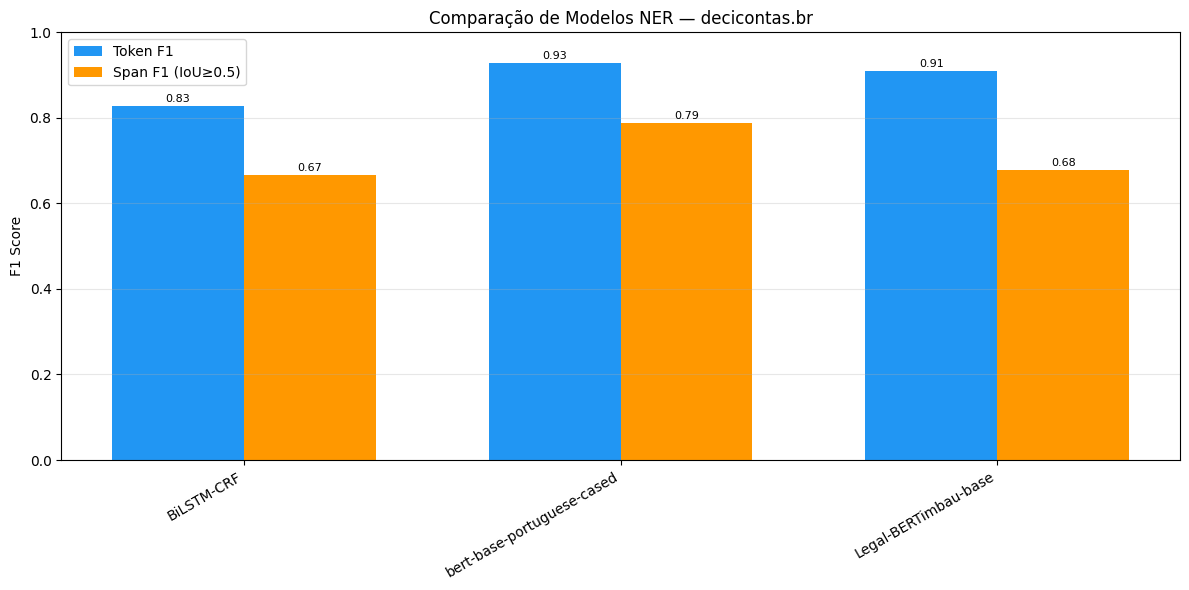

In [41]:
import matplotlib.pyplot as plt

models = [r['model'] for r in all_results]
token_f1s = [r['token_f1'] for r in all_results]
span_f1s = [r['span_f1'] for r in all_results]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, token_f1s, width, label='Token F1', color='#2196F3')
bars2 = ax.bar(x + width/2, span_f1s, width, label='Span F1 (IoU≥0.5)', color='#FF9800')

ax.set_ylabel('F1 Score')
ax.set_title('Comparação de Modelos NER — decicontas.br')
ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in models], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('ner_comparison.png', dpi=150)
plt.show()

In [ ]:
# Salvar resultados em JSON
import json

with open('ner_results_all_models.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print('Resultados salvos em ner_results_all_models.json')